# Experiment Analysis

## Explainable AI Enabled Real-Time Battery Management System

### Objective

The NASA Battery Dataset consists of three different experiment types:

- Charge
- Discharge
- Impedance

Before preprocessing and machine learning, it is necessary to understand the purpose of each experiment and the information it provides.

This notebook analyzes the three experiments and explains how they contribute to State of Charge (SOC), State of Health (SOH), and Remaining Useful Life (RUL) prediction.

In [81]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.core.data_loader import load_csv

In [82]:
discharge_df = load_csv("05122.csv")

charge_df = load_csv("05123.csv")

impedance_df = load_csv("05161.csv")

# Discharge Experiment

During a discharge experiment, the battery delivers electrical energy to an external load.

The battery voltage gradually decreases while the discharge current flows through the load.

The discharge experiment provides important information regarding:

- Energy consumption
- Battery capacity
- State of Charge (SOC)
- Remaining Useful Life (RUL)

In [83]:
discharge_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


In [84]:
discharge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Voltage_measured      197 non-null    float64
 1   Current_measured      197 non-null    float64
 2   Temperature_measured  197 non-null    float64
 3   Current_load          197 non-null    float64
 4   Voltage_load          197 non-null    float64
 5   Time                  197 non-null    float64
dtypes: float64(6)
memory usage: 9.4 KB


In [85]:
discharge_df.isnull().sum()

Voltage_measured        0
Current_measured        0
Temperature_measured    0
Current_load            0
Voltage_load            0
Time                    0
dtype: int64

In [86]:
discharge_df.describe()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,3.529829,-1.818702,32.572328,-1.805570,2.404944,1812.087497
std,0.236558,0.595058,3.495804,0.591217,0.796974,1069.272600
min,2.612467,-2.018015,24.325993,-1.998400,0.000000,0.000000
25%,3.418746,-2.013447,30.422589,-1.998200,2.498000,891.812000
50%,3.529903,-2.012427,32.865786,-1.998200,2.610000,1796.328000
75%,3.685214,-2.011144,35.095568,-1.998200,2.765000,2724.203000
max,4.191492,0.000729,38.982181,-0.000400,4.206000,3690.234000


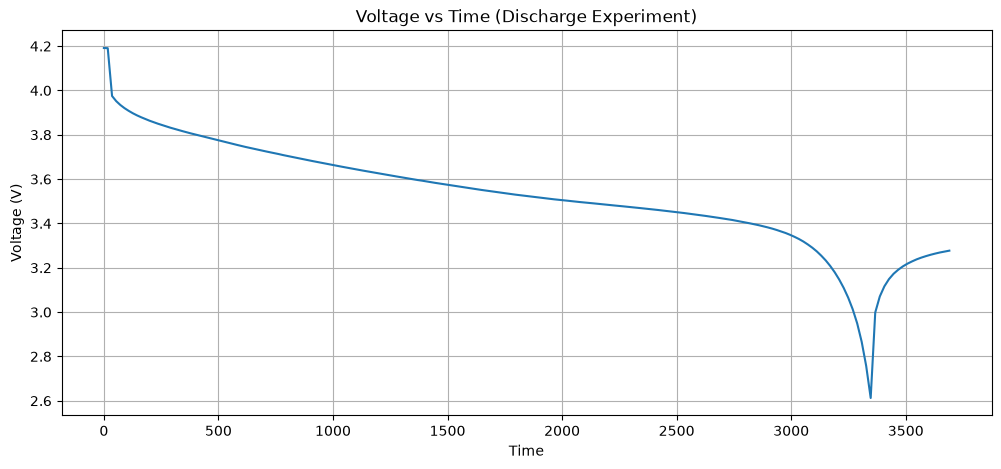

In [87]:
plt.figure(figsize=(12,5))

plt.plot(
    discharge_df["Time"],
    discharge_df["Voltage_measured"]
)

plt.title("Voltage vs Time (Discharge Experiment)")

plt.xlabel("Time")

plt.ylabel("Voltage (V)")

plt.grid(True)

plt.show()

### Observation – Voltage vs Time

The graph shows a gradual decrease in battery voltage as time progresses during the discharge cycle.

This behaviour is expected because the battery is continuously supplying energy to an external load. As stored energy decreases, the terminal voltage also decreases.

This characteristic is one of the primary indicators used for estimating the **State of Charge (SOC)** of the battery.

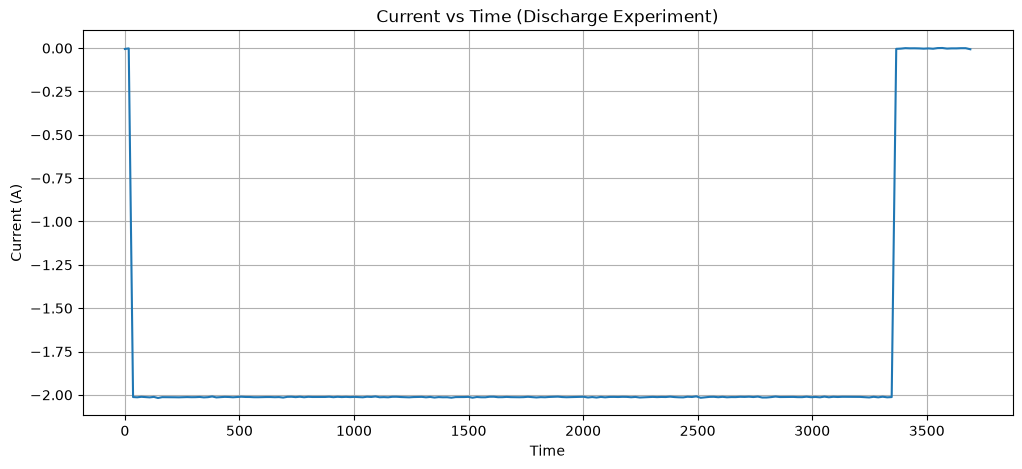

In [88]:
plt.figure(figsize=(12,5))

plt.plot(
    discharge_df["Time"],
    discharge_df["Current_measured"]
)

plt.title("Current vs Time (Discharge Experiment)")

plt.xlabel("Time")

plt.ylabel("Current (A)")

plt.grid(True)

plt.show()

### Observation – Current vs Time

The discharge current remains nearly constant throughout the experiment.

A nearly constant discharge current indicates that the battery was discharged under controlled laboratory conditions, allowing consistent measurement of battery behaviour.

Stable current profiles help improve the reliability of machine learning models for battery analysis.

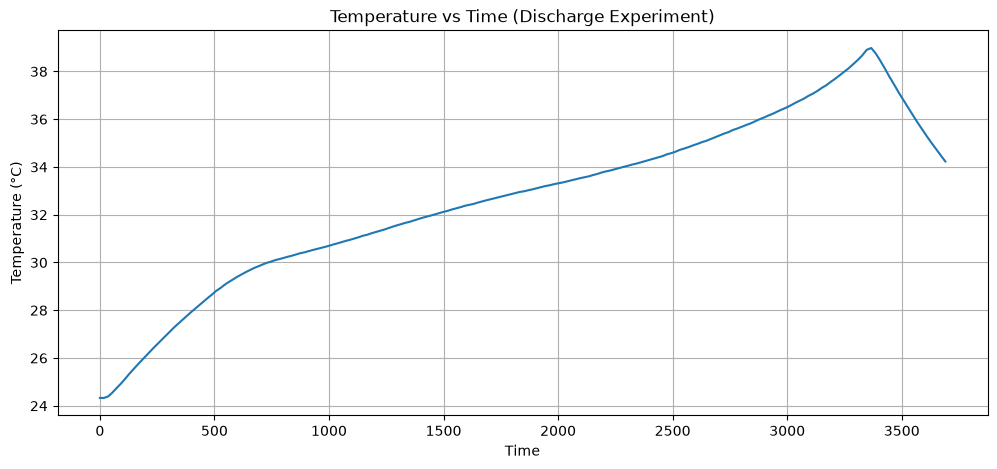

In [89]:
plt.figure(figsize=(12,5))

plt.plot(
    discharge_df["Time"],
    discharge_df["Temperature_measured"]
)

plt.title("Temperature vs Time (Discharge Experiment)")

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

### Observation – Temperature vs Time

Battery temperature increases slightly during the discharge process due to electrochemical reactions and internal resistance.

Monitoring temperature is important because excessive temperature accelerates battery degradation and affects both **SOH** and **RUL** estimation.

### Observations

1. Battery voltage decreases continuously during discharge.

2. Current remains nearly constant throughout the experiment.

3. Battery temperature increases slowly because of electrochemical reactions.

4. The discharge curve represents the usable energy remaining in the battery.

5. This experiment will later be used for SOC estimation and RUL prediction.

# Charge Experiment

## Objective

A charge experiment represents the process of supplying electrical energy to the battery.

During charging, the battery stores energy and its terminal voltage gradually increases until it reaches the fully charged state.

The charge experiment is useful for studying:

- Charging characteristics
- Battery capacity
- Charging efficiency
- State of Health (SOH)
- Capacity degradation

The Smart Battery Management System uses charging data to monitor battery behaviour and estimate long-term battery health.

In [90]:
charge_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.325055,0.000302,29.341851,-0.002,0.003,0.000
1,3.001951,-3.361983,29.335723,-3.370,1.414,2.516
2,3.434644,1.508670,29.334717,1.498,4.142,5.500
3,3.454857,1.510043,29.341949,1.498,4.180,8.391
4,3.468788,1.508704,29.331462,1.498,4.196,11.266


In [91]:
charge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Voltage_measured      940 non-null    float64
 1   Current_measured      940 non-null    float64
 2   Temperature_measured  940 non-null    float64
 3   Current_charge        940 non-null    float64
 4   Voltage_charge        940 non-null    float64
 5   Time                  940 non-null    float64
dtypes: float64(6)
memory usage: 44.2 KB


In [92]:
charge_df.isnull().sum()

Voltage_measured        0
Current_measured        0
Temperature_measured    0
Current_charge          0
Voltage_charge          0
Time                    0
dtype: int64

In [93]:
charge_df.describe()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
count,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.058826,0.949043,26.635623,0.941762,4.430904,3685.339534
std,0.177474,0.666615,1.358494,0.662025,0.710712,3098.497737
min,3.001951,-3.361983,24.528515,-3.370000,0.003000,0.000000
25%,3.939995,0.169820,25.311838,0.168500,4.294000,901.554500
50%,4.139956,1.508142,26.649157,1.498000,4.575000,2846.617000
75%,4.206038,1.510696,27.600352,1.500000,4.710000,6077.410000
max,4.213016,1.515178,29.341949,1.500000,4.931000,10516.000000


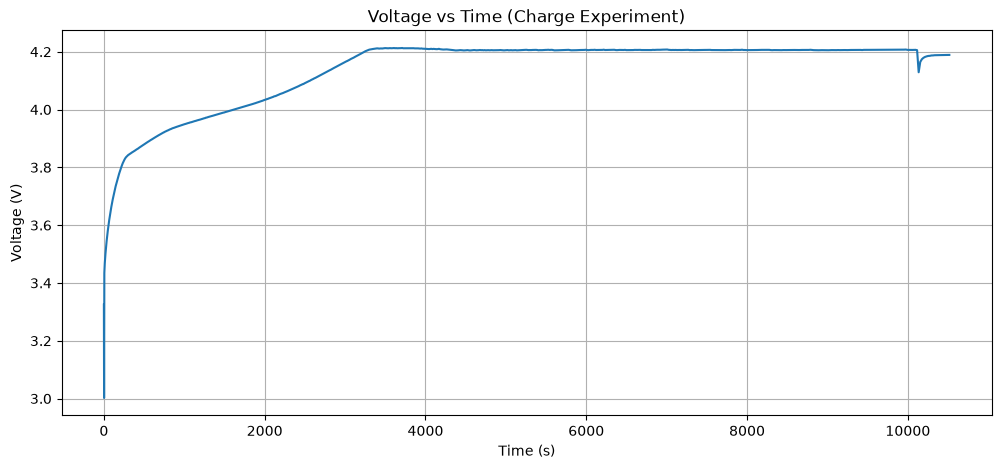

In [94]:
plt.figure(figsize=(12,5))

plt.plot(
    charge_df["Time"],
    charge_df["Voltage_measured"]
)

plt.title("Voltage vs Time (Charge Experiment)")

plt.xlabel("Time (s)")

plt.ylabel("Voltage (V)")

plt.grid(True)

plt.show()

### Observation – Voltage vs Time

The battery voltage gradually increases during the charging cycle until it approaches the fully charged state.

This behaviour represents the normal charging characteristics of a lithium-ion battery operating under constant current and constant voltage charging.

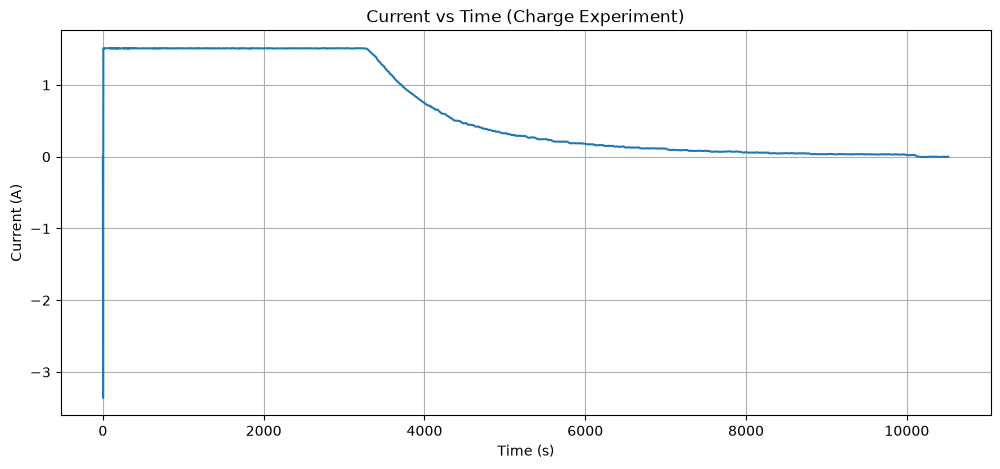

In [95]:
plt.figure(figsize=(12,5))

plt.plot(
    charge_df["Time"],
    charge_df["Current_measured"]
)

plt.title("Current vs Time (Charge Experiment)")

plt.xlabel("Time (s)")

plt.ylabel("Current (A)")

plt.grid(True)

plt.show()

### Observation – Current vs Time

The charging current follows the charging profile applied during the experiment.

Changes in charging current help identify charging efficiency and battery ageing characteristics, making this information useful for **State of Health (SOH)** estimation.

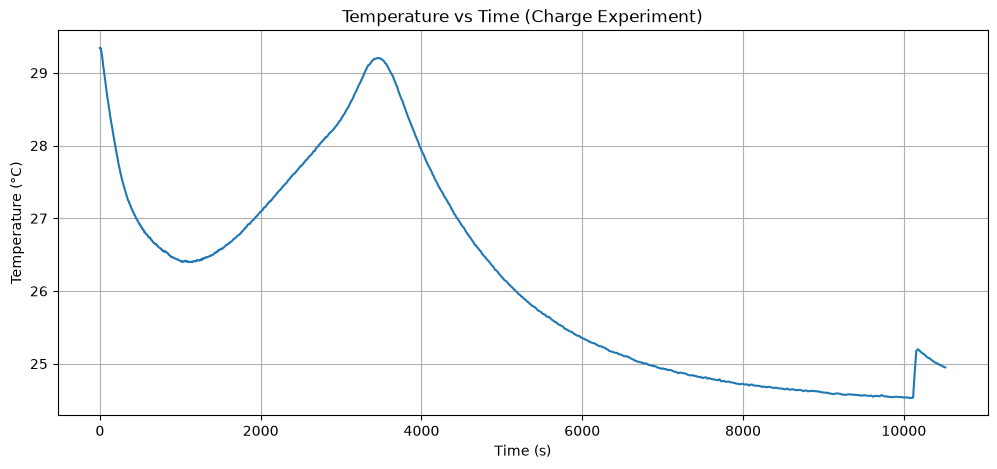

In [96]:
plt.figure(figsize=(12,5))

plt.plot(
    charge_df["Time"],
    charge_df["Temperature_measured"]
)

plt.title("Temperature vs Time (Charge Experiment)")

plt.xlabel("Time (s)")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

### Observation – Temperature vs Time

The battery temperature remains within a safe operating range while charging.

Temperature monitoring is important because higher temperatures accelerate battery degradation and reduce battery lifespan.

### Observations

1. The battery voltage gradually increases during the charging process.

2. Charging current remains controlled according to the charging profile.

3. Battery temperature increases slightly due to electrochemical reactions occurring during charging.

4. Charging behaviour changes as the battery ages, making these experiments useful for monitoring battery degradation.

5. The proposed Smart Battery Management System will use charging data for State of Health (SOH) estimation and capacity analysis.

# Impedance Experiment

## Objective

Unlike charge and discharge experiments, the impedance experiment measures the internal electrochemical characteristics of the battery.

NASA stores these measurements as **complex numbers** because impedance contains both a real component (resistance) and an imaginary component (reactance).

For visualization, the magnitude (absolute value) of the complex impedance is used.

The impedance experiment is useful for:

- State of Health (SOH)
- Battery degradation analysis
- Internal resistance monitoring
- Remaining Useful Life (RUL)

In [97]:
impedance_df.head()

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j)
1,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j)
2,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j)
3,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j)
4,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j)


In [98]:
impedance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sense_current        48 non-null     str  
 1   Battery_current      48 non-null     str  
 2   Current_ratio        48 non-null     str  
 3   Battery_impedance    48 non-null     str  
 4   Rectified_Impedance  39 non-null     str  
dtypes: str(5)
memory usage: 2.0 KB


In [99]:
impedance_df.describe()

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
count,48,48,48,48,39
unique,48,48,48,48,39
top,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j)
freq,1,1,1,1,1


In [100]:
import numpy as np

complex_columns = [
    "Sense_current",
    "Battery_current",
    "Current_ratio",
    "Battery_impedance",
    "Rectified_Impedance"
]

for col in complex_columns:
    impedance_df[col] = impedance_df[col].apply(complex)

In [101]:
for col in complex_columns:
    impedance_df[col + "_Magnitude"] = np.abs(impedance_df[col])

impedance_df.head()

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,Sense_current_Magnitude,Battery_current_Magnitude,Current_ratio_Magnitude,Battery_impedance_Magnitude,Rectified_Impedance_Magnitude
0,-1.000000+ 1.000000j,-1.000000+ 1.000000j,1.000000+0.000000j,-0.438926-0.107298j,0.070069-0.000480j,1.414214,1.414214,1.000000,0.451851,0.070071
1,820.609497- 36.234550j,337.091461- 82.920776j,2.320415+0.463305j,0.130088-0.197115j,0.068179-0.001190j,821.409088,347.140474,2.366215,0.236172,0.068189
2,827.242188- 48.231228j,330.631561- 70.013718j,2.424193+0.367465j,0.058771+0.033307j,0.067933-0.000057j,828.647023,337.963238,2.451885,0.067552,0.067933
3,827.193481- 56.195717j,330.808624- 61.734425j,2.447002+0.286778j,0.005814-0.060547j,0.066918-0.000879j,829.100123,336.519665,2.463749,0.060825,0.066924
4,824.929504- 53.241478j,332.682678- 57.629013j,2.434305+0.261646j,0.126081-0.090444j,0.068071-0.000197j,826.645838,337.637183,2.448326,0.155166,0.068071


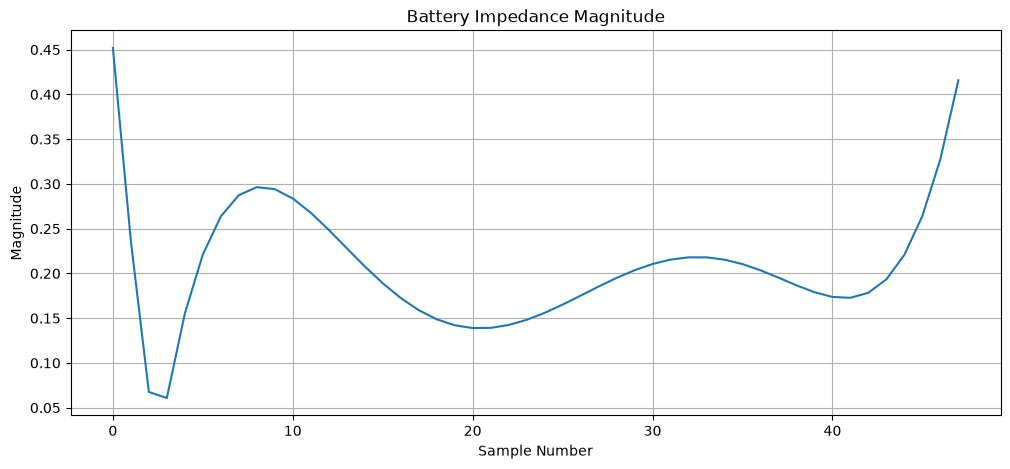

In [102]:
plt.figure(figsize=(12,5))

plt.plot(
    impedance_df["Battery_impedance_Magnitude"]
)

plt.title("Battery Impedance Magnitude")

plt.xlabel("Sample Number")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

### Observation – Battery Impedance Magnitude

The impedance magnitude represents the overall opposition offered by the battery to the flow of alternating current.

As lithium-ion batteries age, the internal impedance generally increases due to electrochemical degradation.

Therefore, impedance is considered one of the most reliable indicators of battery health.

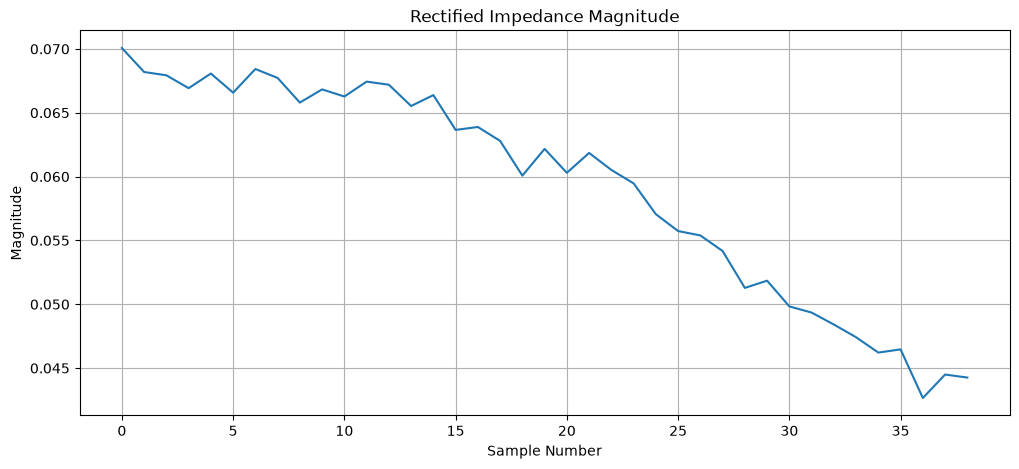

In [103]:
plt.figure(figsize=(12,5))

plt.plot(
    impedance_df["Rectified_Impedance_Magnitude"]
)

plt.title("Rectified Impedance Magnitude")

plt.xlabel("Sample Number")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

### Observation – Rectified Impedance Magnitude

The rectified impedance is a processed version of the raw impedance measurement.

It reduces measurement noise and provides a more stable representation of the battery's internal resistance.

This parameter is useful for accurate **State of Health (SOH)** prediction.

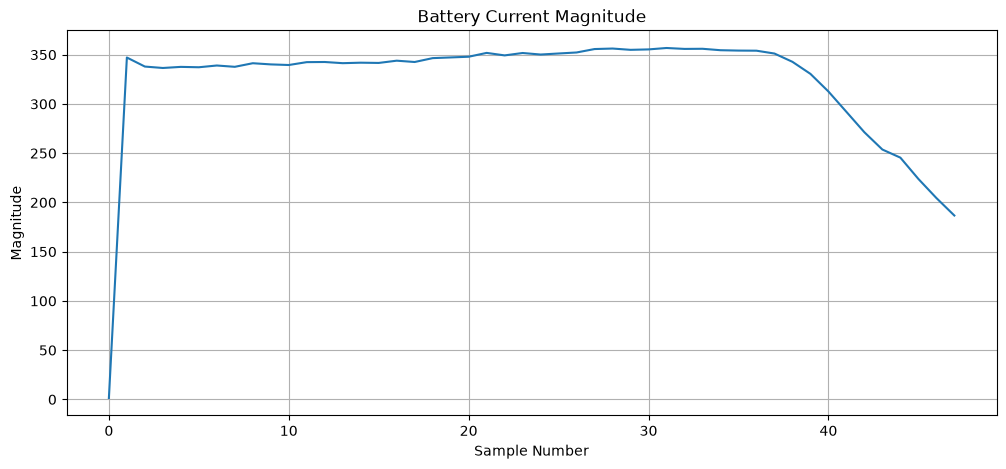

In [104]:
plt.figure(figsize=(12,5))

plt.plot(
    impedance_df["Battery_current_Magnitude"]
)

plt.title("Battery Current Magnitude")

plt.xlabel("Sample Number")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

### Observation – Battery Current Magnitude

The battery current measured during impedance testing represents the electrical response of the battery during Electrochemical Impedance Spectroscopy (EIS).

Unlike charging and discharging experiments, this current is used to estimate electrochemical properties rather than energy transfer.

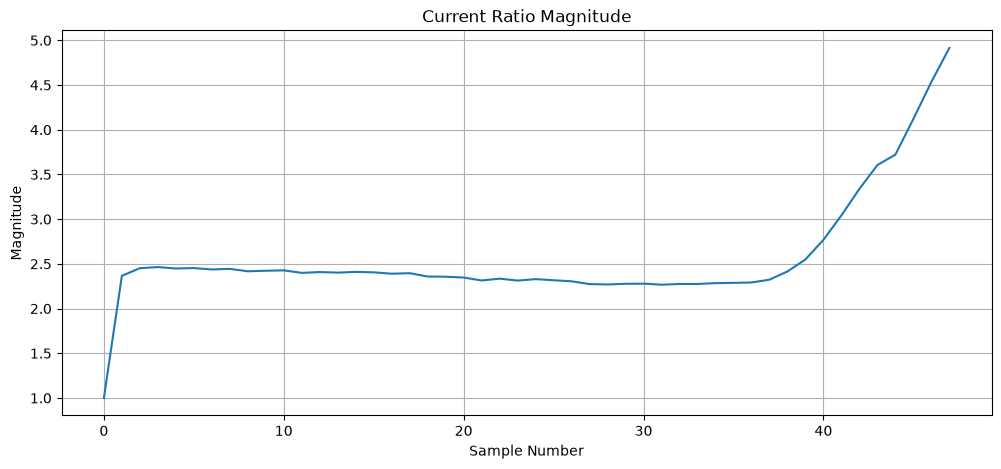

In [105]:
plt.figure(figsize=(12,5))

plt.plot(
    impedance_df["Current_ratio_Magnitude"]
)

plt.title("Current Ratio Magnitude")

plt.xlabel("Sample Number")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

### Observation – Current Ratio

The current ratio represents the relationship between the sensed current and the battery current.

Variations in this parameter help characterize the internal electrical behaviour of the battery and contribute to impedance-based health analysis.

### Observations

1. Unlike charge and discharge experiments, impedance measurements are stored as complex numbers.

2. The real part represents battery resistance while the imaginary part represents the reactive behaviour of the battery.

3. For visualization, the magnitude of the complex impedance is used.

4. Increasing impedance generally indicates battery ageing and degradation.

5. Battery impedance is one of the most important indicators for State of Health (SOH) estimation.

6. The proposed Smart Battery Management System will combine impedance information with charge and discharge data to improve Remaining Useful Life (RUL) prediction.

# Compare All Three Experiments

## Objective

The NASA Battery Dataset consists of three different experiment types:

- Charge
- Discharge
- Impedance

Each experiment provides different information about the battery.

The Smart Battery Management System (SBMS) combines information from all three experiments to estimate:

- State of Charge (SOC)
- State of Health (SOH)
- Remaining Useful Life (RUL)

The following comparison summarizes the role of each experiment.

In [106]:
comparison = pd.DataFrame({
    "Experiment": [
        "Charge",
        "Discharge",
        "Impedance"
    ],

    "Purpose": [
        "Store Energy",
        "Deliver Energy",
        "Measure Internal Resistance"
    ],

    "Important Parameters": [
        "Voltage, Current, Temperature",
        "Voltage, Current, Temperature",
        "Battery Impedance, Battery Current, Current Ratio"
    ],

    "Used For": [
        "SOH Estimation",
        "SOC & RUL Prediction",
        "SOH & RUL Prediction"
    ],

    "Importance in SBMS": [
        "Battery Charging Analysis",
        "Battery Performance Analysis",
        "Battery Ageing Analysis"
    ]
})

comparison

,Experiment,Purpose,Important Parameters,Used For,Importance in SBMS
0,Charge,Store Energy,"Voltage, Current, Temperature",SOH Estimation,Battery Charging Analysis
1,Discharge,Deliver Energy,"Voltage, Current, Temperature",SOC & RUL Prediction,Battery Performance Analysis
2,Impedance,Measure Internal Resistance,"Battery Impedance, Battery Current, Current Ratio",SOH & RUL Prediction,Battery Ageing Analysis


## Comparison Summary

### Charge Experiment

- Stores electrical energy in the battery.
- Used to understand charging characteristics.
- Helps estimate battery capacity and State of Health (SOH).

---

### Discharge Experiment

- Supplies energy from the battery.
- Used to monitor battery performance during usage.
- Important for State of Charge (SOC) estimation and Remaining Useful Life (RUL) prediction.

---

### Impedance Experiment

- Measures the battery's internal electrochemical resistance.
- Internal resistance increases as the battery ages.
- Most useful for State of Health (SOH) estimation.

# Importance of Experiment Analysis

The experiment analysis performed in this notebook provides a clear understanding of the different operational modes present in the NASA Battery Dataset.

Instead of treating all battery cycles as identical, the proposed Smart Battery Management System (SBMS) processes each experiment separately.

This improves:

- Data quality
- Feature extraction
- Model accuracy
- Explainability of AI predictions

The knowledge gained from this analysis forms the basis of the preprocessing pipeline implemented in the next notebook.

# Conclusions for Smart Battery Management System (SBMS)

This notebook analyzed the three experiment types available in the NASA Battery Dataset.

The major observations are:

- Charge experiments provide information about battery charging behaviour.
- Discharge experiments describe battery performance while supplying energy.
- Impedance experiments measure the battery's internal electrochemical condition using complex impedance values.

Each experiment contributes different information required by a Battery Management System.

The proposed Explainable AI-enabled Smart Battery Management System (SBMS) will combine these experiments to develop accurate machine learning models for:

- State of Charge (SOC)
- State of Health (SOH)
- Remaining Useful Life (RUL)

The dataset investigation performed in this notebook establishes the foundation for the preprocessing and feature engineering stages of the project.

In [107]:
summary = pd.DataFrame({

    "Notebook": [
        "Dataset Understanding",
        "Dataset Profiling",
        "Experiment Analysis"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Completed"
    ],

    "Outcome": [
        "Understood NASA Battery Dataset",
        "Identified experiment formats",
        "Studied Charge, Discharge and Impedance experiments"
    ]

})

summary

,Notebook,Status,Outcome
0,Dataset Understanding,Completed,Understood NASA Battery Dataset
1,Dataset Profiling,Completed,Identified experiment formats
2,Experiment Analysis,Completed,"Studied Charge, Discharge and Impedance experi..."


# Key Takeaways

✔ Understood the structure of the NASA Battery Dataset.

✔ Identified three different experiment types.

✔ Analyzed Charge experiments.

✔ Analyzed Discharge experiments.

✔ Analyzed Impedance experiments.

✔ Compared all experiment types.

✔ Prepared the dataset for preprocessing.

